TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

In [13]:
import cv2
import matplotlib.pyplot as plt


In [14]:
# Lee imagen de archivo
img = cv2.imread("mandril.jpg")

# Si hay lectura correcta
if img is not None:
    # Muestra dimensiones
    print(img.shape)

    # Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
else:
    print("Imagen no encontrada")

(512, 512, 3)


In [15]:
# Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)


(512, 512)


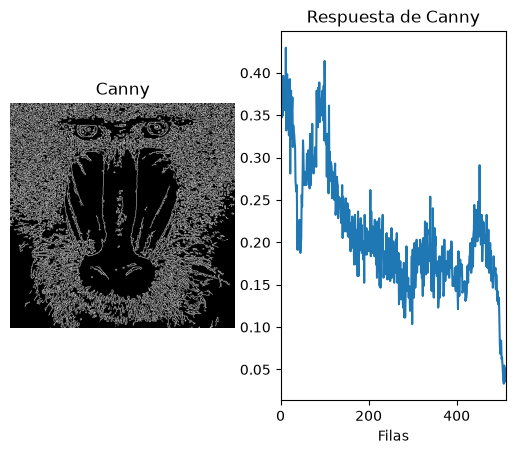

In [16]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

# Cuenta el número de píxeles blancos (255) por fila
white_pixels_per_row = cv2.reduce(canny, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
percentage_per_row = white_pixels_per_row / (255 * canny.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])

plt.show()